In [18]:
import matplotlib.pyplot as plt
from matplotlib.pyplot import legend
from utils_network_processing import *
plt.rcParams.update({'font.size': 30})
import os
from PIL import Image
from pathlib import Path
import ast
from utils_plotting import *
script_dir = Path.cwd().parent

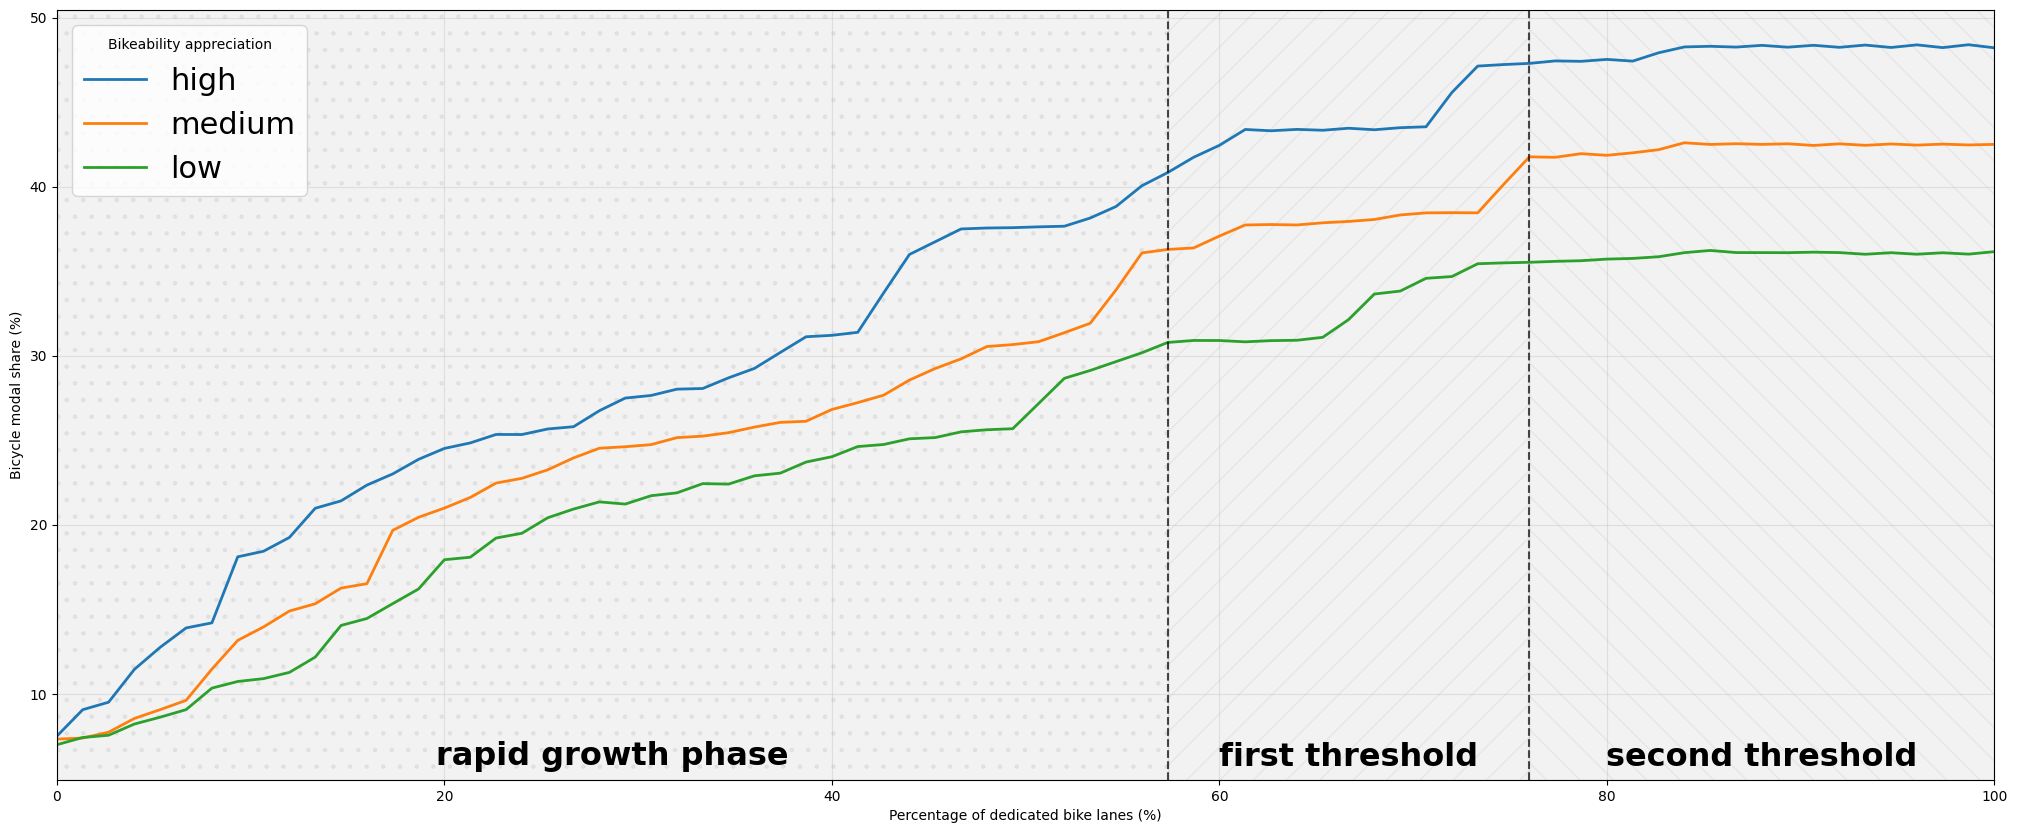

In [13]:
list_name_bi = ['high', 'medium', 'low']
fig, ax = plt.subplots(1, 1, figsize=(25, 10))


total_lanes = 75

for coef_map_num, name_bi in zip(list_coef_map_num, list_name_bi):
    name_test = f"CAP_{city_name}_test_{beta_time}_{ASC_bike}_bi_{coef_map_num}"
    filename = f"output/optimization/test_parametres/{horodatage}/rgo_results_df_opt_{name_test}.csv"
    df = pd.read_csv(script_dir / filename)

    df["pct_bike_lanes"] = (df["nbr_bike_lanes"] / total_lanes) * 100
    ax.plot(df["pct_bike_lanes"], df["modal_share_bike"], linewidth=2, label=name_bi)

ax.set_xlabel("Percentage of dedicated bike lanes (%)")
ax.set_ylabel("Bicycle modal share (%)")
ax.grid(True, alpha=0.3)

zone1 = (43 / total_lanes) * 100
zone2 = (57 / total_lanes) * 100

ax.set_xlim(0, 100)
x_max = ax.get_xlim()[1]
y_min = ax.get_ylim()[0]
y_max = ax.get_ylim()[1]

# Zone 1
ax.axvspan(0, zone1, color="black", hatch=".", alpha=0.05)
ax.text(
    zone1 / 2,
    0.05,
    "rapid growth phase",
    transform=ax.get_xaxis_transform(),
    ha="center",
    va="top",
    fontsize=fontsize - 2,
    fontweight="bold",
)

# Zone 2
ax.axvspan(zone1, zone2, color="black", hatch="/", alpha=0.05)
ax.text(
    (zone1 + zone2) / 2,
    0.05,
    "first threshold",
    transform=ax.get_xaxis_transform(),
    ha="center",
    va="top",
    fontsize=fontsize - 2,
    fontweight="bold",
)

# Zone 3
ax.axvspan(zone2, x_max, color="black", hatch="\\", alpha=0.05)
ax.text(
    (zone2 + x_max) / 2,
    0.05,
    "second threshold",
    transform=ax.get_xaxis_transform(),
    ha="center",
    va="top",
    fontsize=fontsize - 2,
    fontweight="bold",
)

ax.set_xlim(0, x_max)
ax.legend(loc="upper left", title="Bikeability appreciation", fontsize=fontsize - 3)

ax.axvline(x=zone1, color="black", linestyle="--", linewidth=1.5, alpha=0.7)
ax.axvline(x=zone2, color="black", linestyle="--", linewidth=1.5, alpha=0.7)

plt.show()

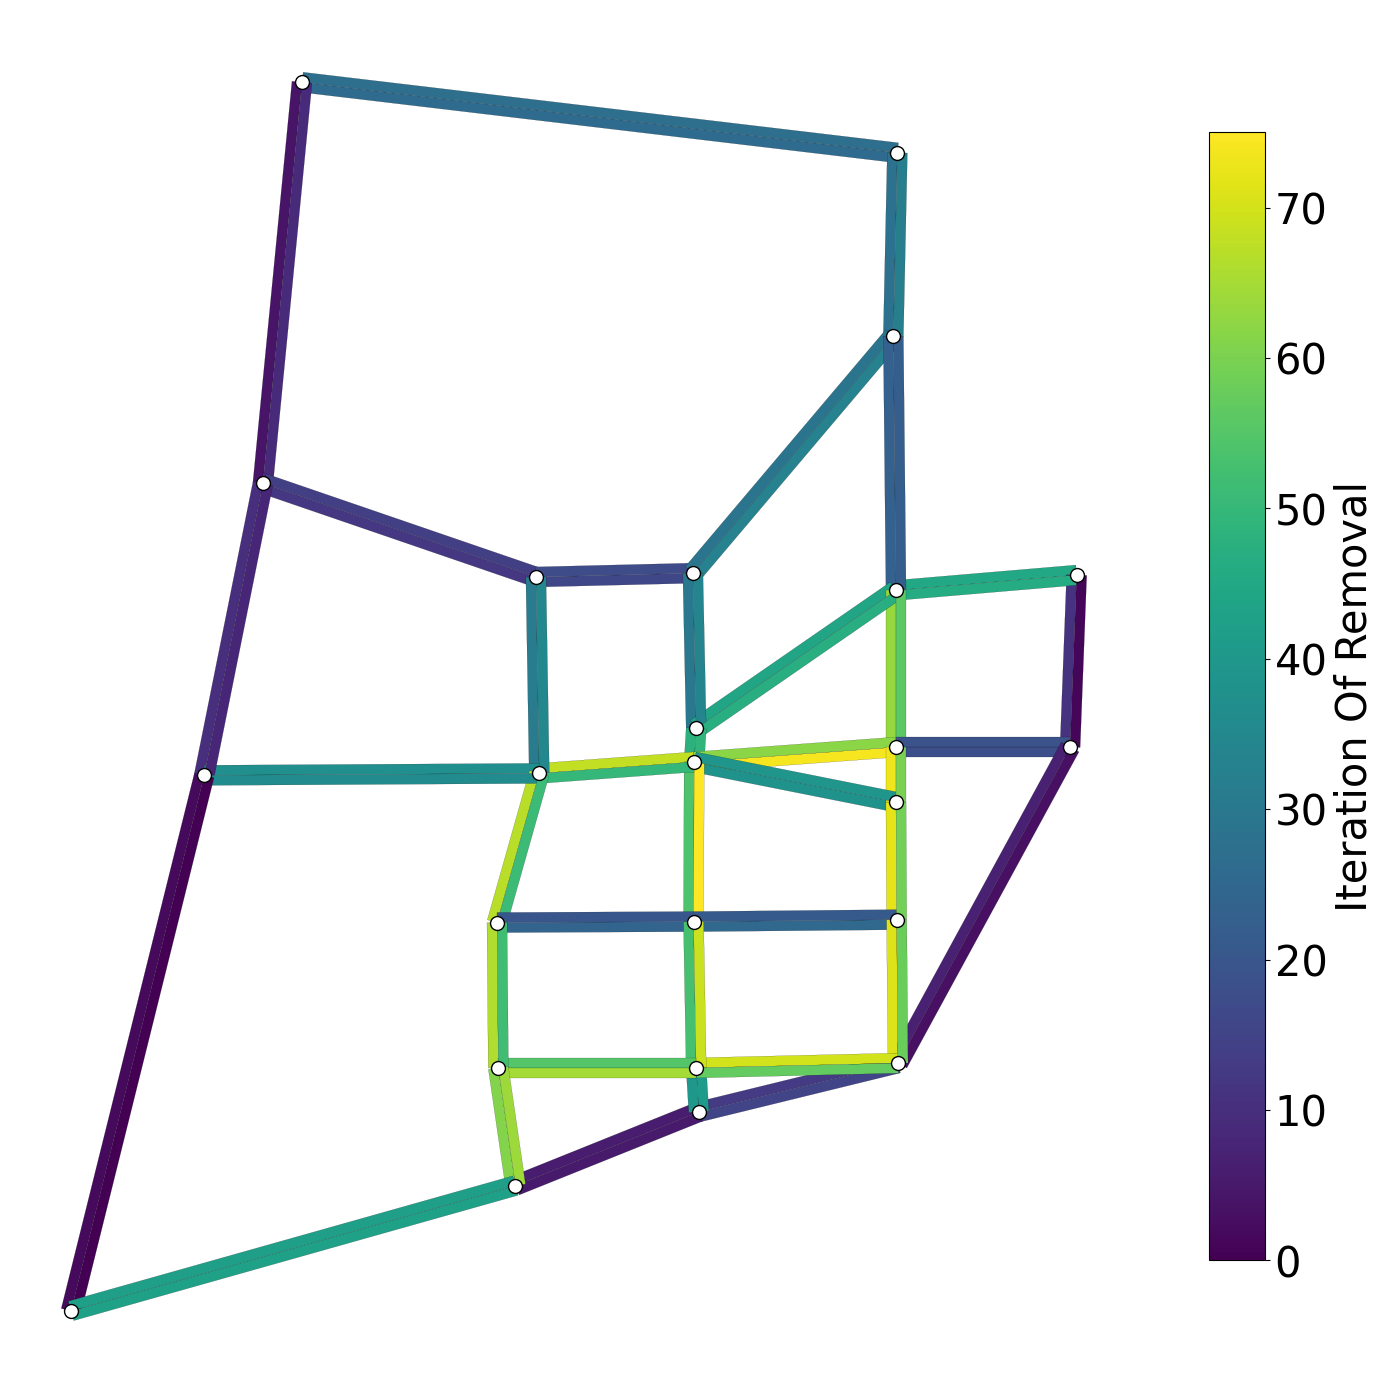

In [19]:
edge_df, node_df = import_network(script_dir / f"data/{city_name}/edges_{city_name}.csv", script_dir / f"data/{city_name}/nodes_{city_name}.csv", real_network=True)
edge_df['existing_bike_infra']=False
edge_df['type_bike']=None
edge_df_results = pd.read_csv(script_dir / "output/optimization/test_parametres/2026-08-27_14-16-45/rgo_edge_df_results_CAP_Sioux_Falls_test_-0.001_-2_bi_21.csv")
results_df_opt = pd.read_csv(script_dir / f"output/optimization/test_parametres/2026-08-27_14-16-45/rgo_results_df_opt_CAP_Sioux_Falls_test_-0.001_-2_bi_21.csv")
results_df_opt.drop("Unnamed: 0", axis=1, inplace=True)
results_df_opt = results_df_opt.iloc[1:].reset_index(drop=True)
results_df_opt["index_removed"] = results_df_opt["index_removed"].apply(ast.literal_eval)
results_df_opt = results_df_opt.explode('index_removed')
edge_df_existing = edge_df[edge_df["existing_bike_infra"]]
edge_df = edge_df.merge(results_df_opt, how="inner", left_on="id", right_on="index_removed")
edge_df.index = edge_df["id"]
edge_df.drop(
        ["nbr_bike_lanes", "nbr_none_bike_lanes", "modal_share_car", "modal_share_bike",
         "index_removed",
         "flow_of_removed_edge"], axis=1, inplace=True)
edge_df.rename(columns={'iteration': 'iteration_of_removal'}, inplace=True)
fig, ax = plt.subplots(1, 1, figsize=(15, 15))
plot_network(edge_df, node_df, node_id_col='id',
                     node_label=False,
                     color_col_num='iteration_of_removal',
                     base_width=1,
                     legend=True,
                     title=f"",
                 ax=ax, show_nodes=True)